In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO RETURNING CUSTOMERS (Quotes spanning >30 days)
print("\n🎯 FILTERING TO RETURNING CUSTOMERS (Quotes spanning >30 days)")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Calculate date range per customer
date_range = df_quotes.groupby('numero_compte')['dt_creation_devis'].agg(['min', 'max'])
date_range['days_span'] = (date_range['max'] - date_range['min']).dt.days

# Get customers with quotes spanning >30 days
returning_ids = date_range[date_range['days_span'] > 30].index.tolist()

# Filter data
df_quotes_returning = df_quotes[df_quotes['numero_compte'].isin(returning_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Returning customers (span >30 days): {len(returning_ids):,}")
print(f"Quotes: {len(df_quotes_returning):,}")

# Save to file
df_quotes_returning.to_csv('cleaned_quote_data_returning.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_returning.csv")


🎯 FILTERING TO RETURNING CUSTOMERS (Quotes spanning >30 days)
Original customers: 25,716
Returning customers (span >30 days): 2,095
Quotes: 6,158

✅ Saved to cleaned_quote_data_returning.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_returning.csv')


📊 Original quote data: 6,158 quotes from 2,095 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 2,095, Quotes: 5,462
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 2,095 customers | 66.1% converters
⏱️  Execution time: 0.9 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 2,095
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/2,095 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 2,095
   First converters: 1,385 (66.1%)
   Never converters: 710

📊 Distribution check:
   Converters with 0 historical quotes: 528
   Non-converters with 0 historical quotes: 0
   Avg historical quotes - Converters: 1.0
   Avg historical quotes - Non-converters: 1.9

✅ L

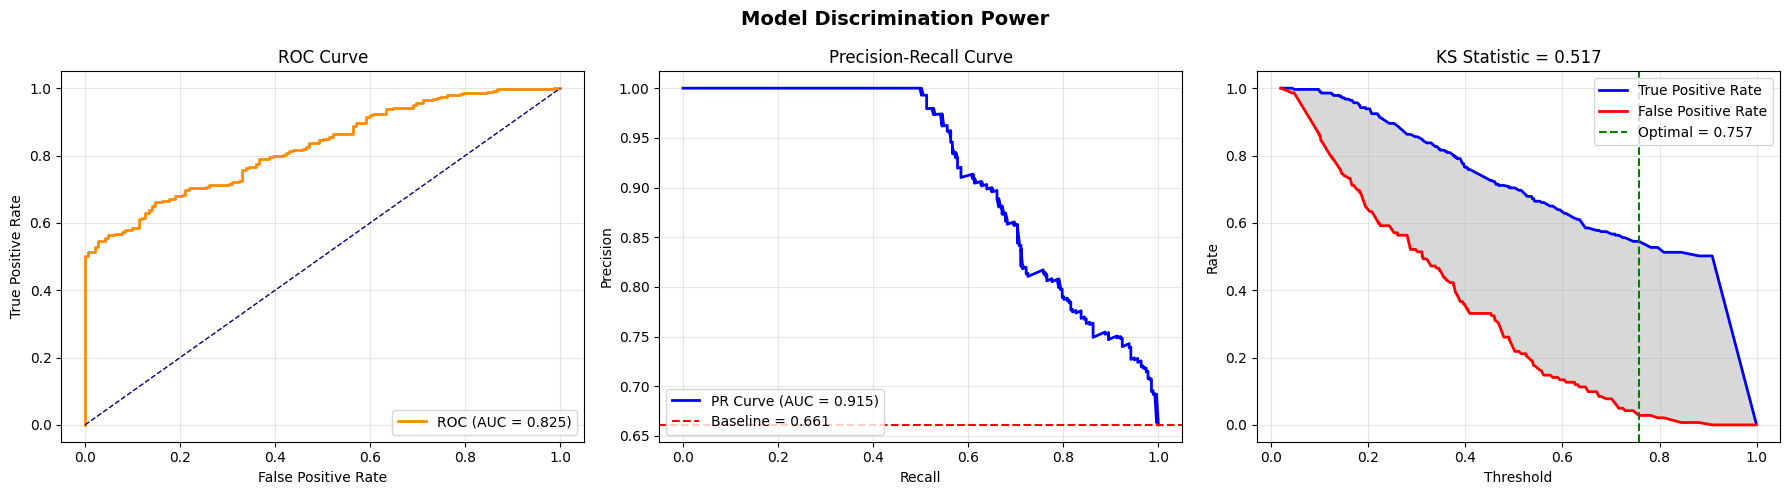

• ROC-AUC: 0.8245
• PR-AUC: 0.9154
• KS Statistic: 0.517 (EXCELLENT discrimination)
• Optimal Threshold: 0.757

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.998
Decile 10 mean prob: 0.094


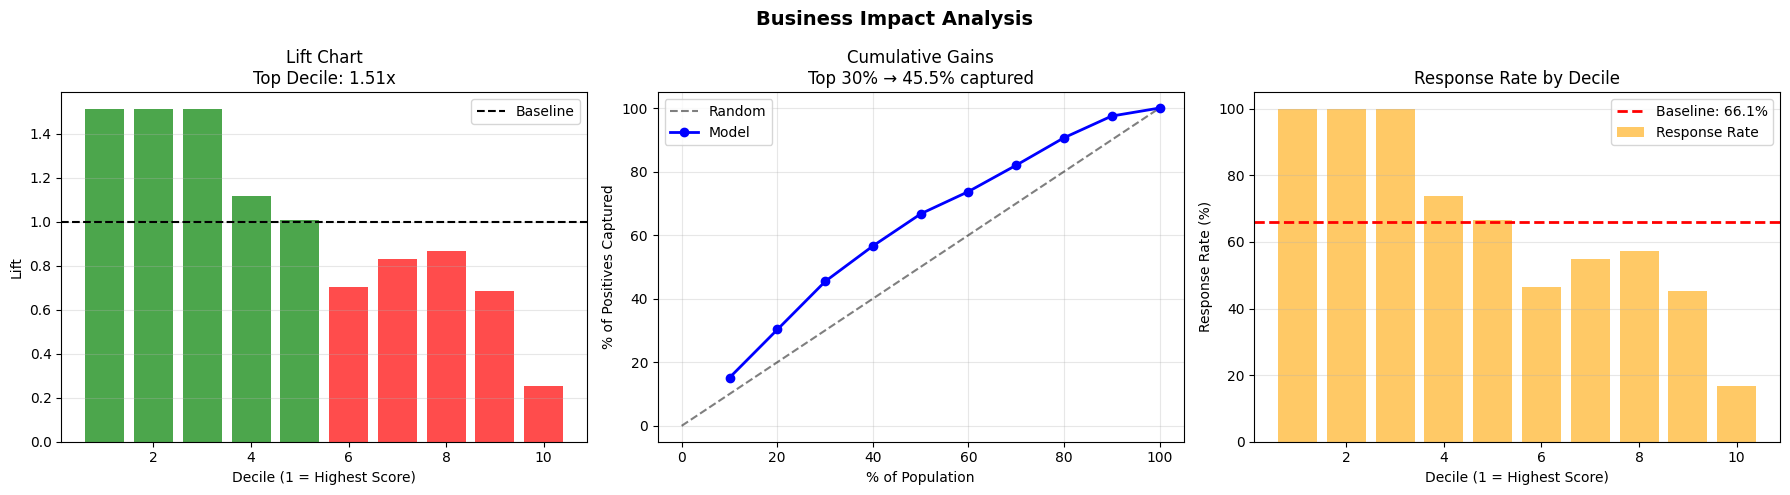

• Top Decile Lift: 0.25x
• Top 30% captures: 45.5% of positives
• Baseline response rate: 66.1%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


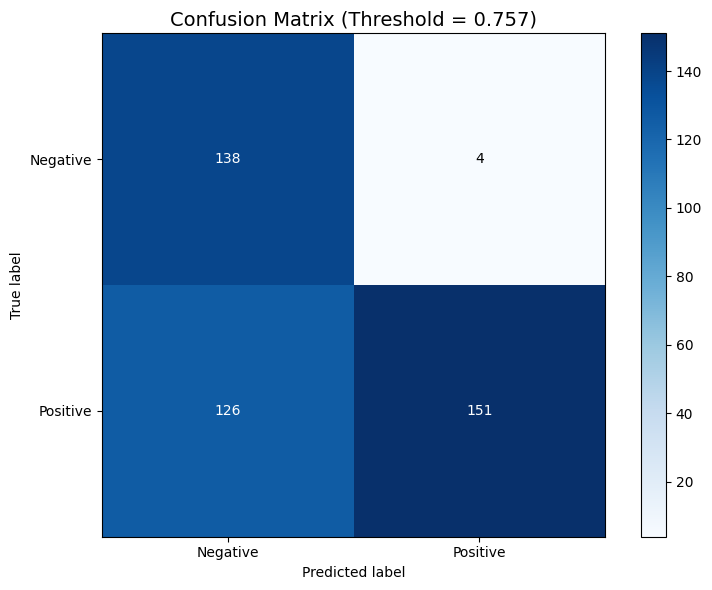

At threshold 0.757:
• Accuracy: 0.690
• Precision: 0.974
• Recall: 0.545
• F1-Score: 0.699
• True Positives: 151
• False Positives: 4
• True Negatives: 138
• False Negatives: 126

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.517 (EXCELLENT discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.25x better than random
   Coverage: Top 30% → 45.5% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.8245 (Excellent if >0.8)
   PR-AUC: 0.9154 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.757
   Precision at threshold: 0.974
   Recall at threshold: 0.545

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                         feature  importance
176      quote_consistency_score    0.148326
157                  price_range    0.025439
2        unique_product_families    0.012601
177      quote_price_sensitivity    0.012355
0        std_days_between_quotes    0.010675
43    model_sophistication_score    0.010089
13          avg_recent_avg_price    

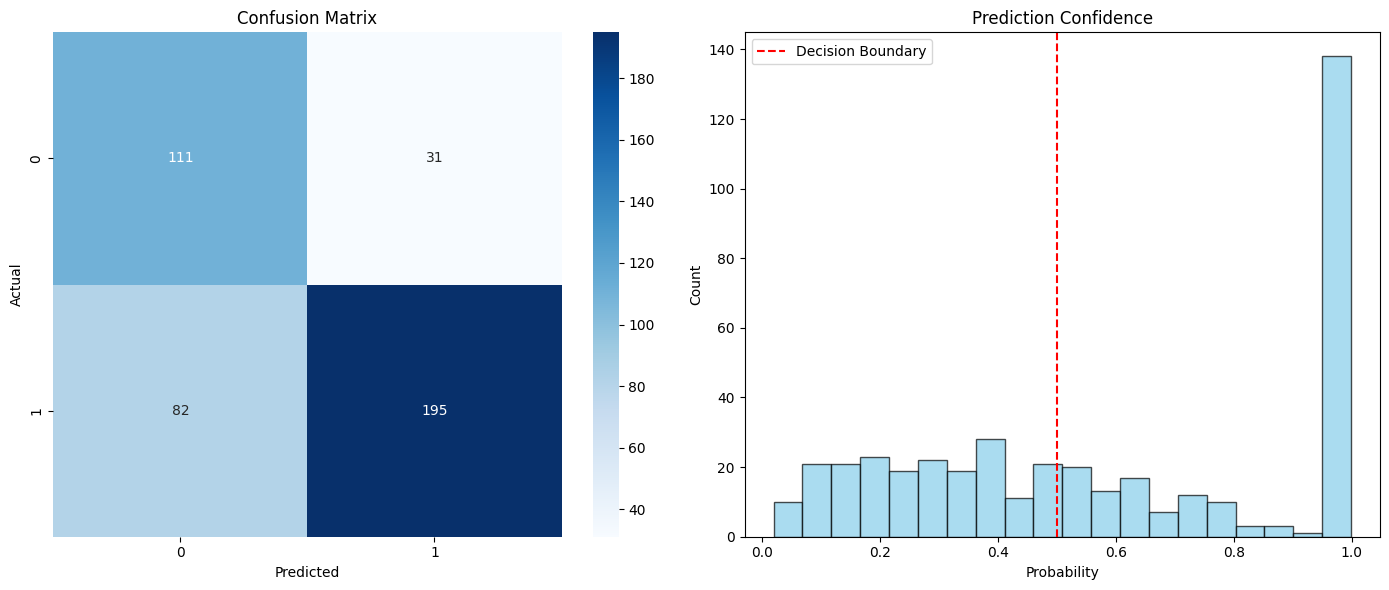

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])